In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv('../../data/data.csv')
data.head()

,timestamp_ms,accel_x_g,accel_y_g,accel_z_g,gyro_x_dps,gyro_y_dps,gyro_z_dps,temperature_c
0,2,0.2800,-0.0410,1.0305,41.3282,8.2901,-1.1069,41.94
1,13,0.3298,-0.1404,1.0950,138.2748,29.3053,-5.9618,41.99
2,24,0.2175,-0.0413,1.1360,250.1298,69.2061,-7.1908,41.75
3,35,0.0195,-0.1580,1.1548,250.1298,119.2214,-9.1221,41.71
4,46,0.0229,-0.0725,1.0710,250.1298,148.9008,-39.0992,41.94


In [3]:
def filter(data):
    """Apply a simple moving average filter to the data."""
    window_size = 5
    return data.rolling(window=window_size).mean()

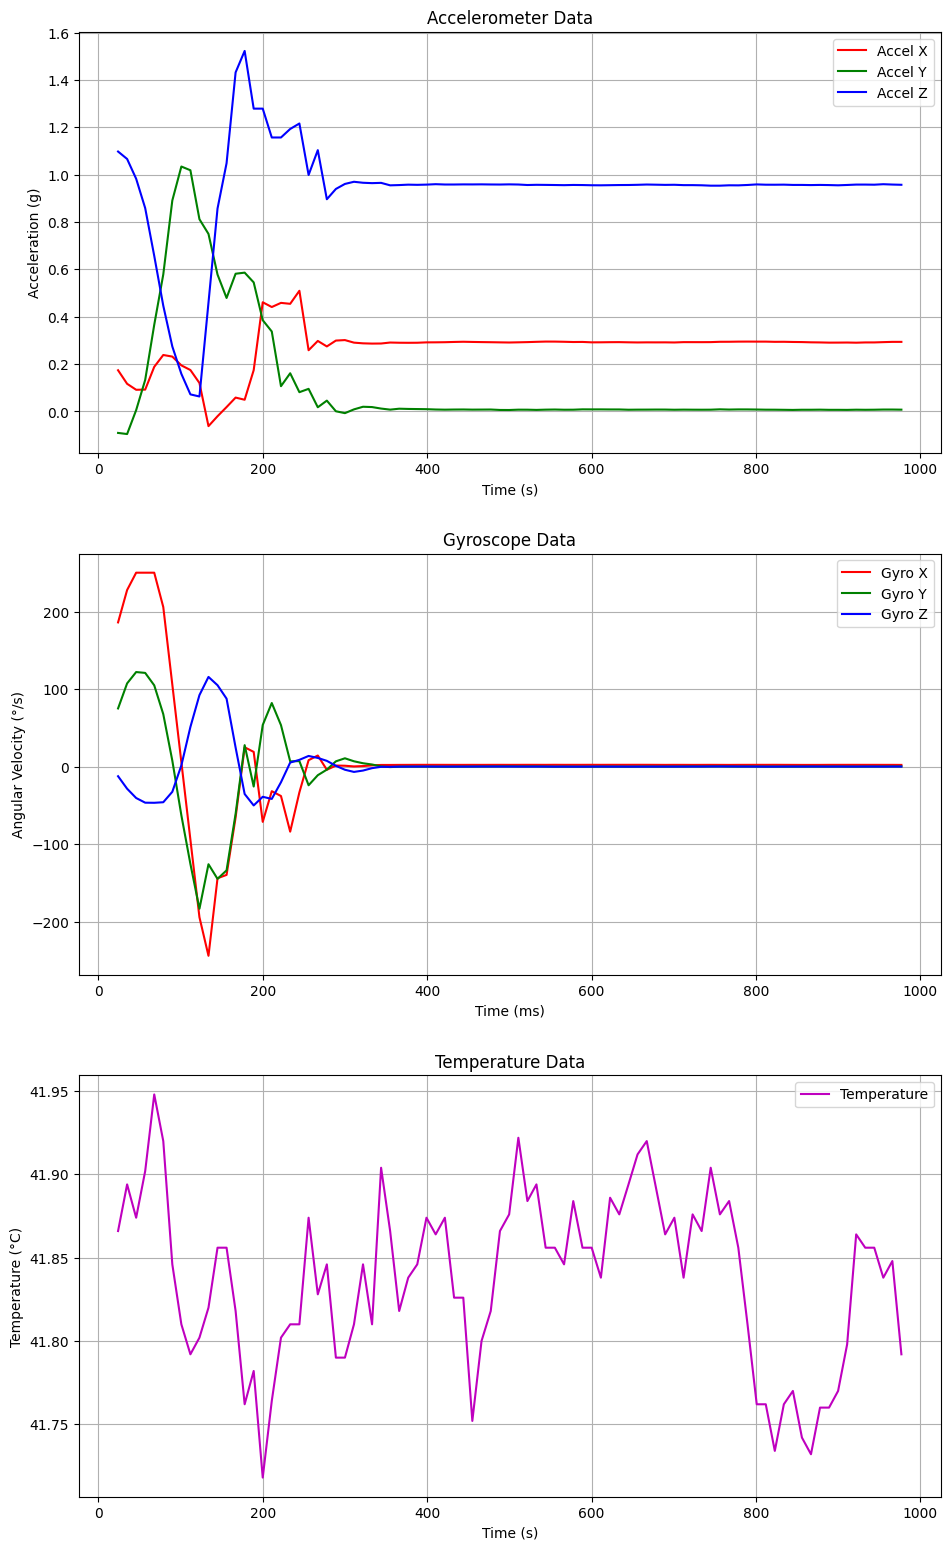

In [4]:
def plot_filtered_data_from_csv(data):
    data = filter(data)

    # Extract time and sensor data
    time = data['timestamp_ms']
    ax = data['accel_x_g']
    ay = data['accel_y_g']
    az = data['accel_z_g']
    gx = data['gyro_x_dps']
    gy = data['gyro_y_dps']
    gz = data['gyro_z_dps']
    temp = data['temperature_c']

    # Create subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 16))

    # Plot accelerometer data
    ax1.plot(time, ax, label='Accel X', color='r')
    ax1.plot(time, ay, label='Accel Y', color='g')
    ax1.plot(time, az, label='Accel Z', color='b')
    ax1.set_title('Accelerometer Data')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Acceleration (g)')
    ax1.legend()
    ax1.grid()

    # Plot gyroscope data
    ax2.plot(time, gx, label='Gyro X', color='r')
    ax2.plot(time, gy, label='Gyro Y', color='g')
    ax2.plot(time, gz, label='Gyro Z', color='b')
    ax2.set_title('Gyroscope Data')
    ax2.set_xlabel('Time (ms)')
    ax2.set_ylabel('Angular Velocity (°/s)')
    ax2.legend()
    ax2.grid()

    # Plot temperature data
    ax3.plot(time, temp, label='Temperature', color='m')
    ax3.set_title('Temperature Data')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Temperature (°C)')
    ax3.legend()
    ax3.grid()

    # Adjust layout to increase spacing between subplots/figures
    fig.subplots_adjust(hspace=0.5)
    fig.tight_layout(pad=2.5)

    # Show plots
    plt.show()

    # save plots to file
    fig.savefig('../../docs/results/filtered/plots_filtered.png')

plot_filtered_data_from_csv(data)